# Week 2: Data Preprocessing & SMOTE
**Goal:** Split data correctly, scale features, handle class imbalance using SMOTE  
**Key Rule:** ALWAYS split BEFORE applying SMOTE — never after (data leakage!)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [3]:
df = pd.read_csv('data/creditcard.csv')
print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean()*100:.3f}%")

✅ Dataset loaded: 284,807 rows × 31 columns

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.173%


## Step 1: Separate Features and Target
- **X** = all input features (V1-V28, Time, Amount)
- **y** = target column (Class: 0=legit, 1=fraud)

In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

print(f"✅ Features shape (X): {X.shape}")
print(f"✅ Target shape  (y): {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")

✅ Features shape (X): (284807, 30)
✅ Target shape  (y): (284807,)

Feature columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


## Step 2: Train / Validation / Test Split (70 / 15 / 15)
**WHY we split BEFORE SMOTE:**  
If you apply SMOTE first, synthetic fraud samples leak into your test set.  
Your model then gets tested on data it has "seen" indirectly → fake high accuracy.  
Always split first → apply SMOTE only on training data.

In [5]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y  # keeps fraud ratio same in all splits
)

# Second split: 50% of temp = 15% val, 50% of temp = 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("✅ Data split complete!")
print(f"\nTraining set:   {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nFraud in train: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Fraud in val:   {y_val.sum()} ({y_val.mean()*100:.3f}%)")
print(f"Fraud in test:  {y_test.sum()} ({y_test.mean()*100:.3f}%)")

✅ Data split complete!

Training set:   199,364 rows (70.0%)
Validation set: 42,721 rows (15.0%)
Test set:       42,722 rows (15.0%)

Fraud in train: 344 (0.173%)
Fraud in val:   74 (0.173%)
Fraud in test:  74 (0.173%)


## Step 3: Feature Scaling with StandardScaler
**Why scale?**  
- `Amount` ranges from $0 to $25,000  
- V1-V28 are already PCA-transformed (small values)  
- Without scaling, `Amount` dominates and confuses the model  
- StandardScaler converts everything to mean=0, std=1

**Rule:** Fit scaler on TRAIN only → transform train, val, test  
Never fit on val/test — that would leak test distribution into training!

In [6]:
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)
# Transform val and test using train's scale
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling complete!")
print(f"\nBefore scaling — Amount mean: {X_train['Amount'].mean():.2f}, std: {X_train['Amount'].std():.2f}")
print(f"After scaling  — Amount mean: {X_train_scaled[:, -1].mean():.4f}, std: {X_train_scaled[:, -1].std():.4f}")

✅ Scaling complete!

Before scaling — Amount mean: 88.38, std: 253.07
After scaling  — Amount mean: 0.0000, std: 1.0000


## Step 4: Apply SMOTE on Training Data ONLY
**What is SMOTE?**  
SMOTE = Synthetic Minority Over-sampling Technique  
It creates **synthetic** (artificial but realistic) fraud transactions  
by interpolating between existing fraud samples.

**Why not just duplicate fraud rows?**  
Simple duplication = model memorizes exact rows = overfitting  
SMOTE = creates NEW slightly different samples = better generalisation

**We apply it ONLY on X_train — never on val or test!**

In [7]:
print("Applying SMOTE on training data...")
print(f"Before SMOTE — Legit: {(y_train==0).sum():,} | Fraud: {(y_train==1).sum():,}")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"\n✅ After SMOTE  — Legit: {(y_train_smote==0).sum():,} | Fraud: {(y_train_smote==1).sum():,}")
print(f"New training set size: {len(X_train_smote):,} rows")
print(f"Fraud percentage after SMOTE: {y_train_smote.mean()*100:.1f}%")

Applying SMOTE on training data...
Before SMOTE — Legit: 199,020 | Fraud: 344

✅ After SMOTE  — Legit: 199,020 | Fraud: 199,020
New training set size: 398,040 rows
Fraud percentage after SMOTE: 50.0%


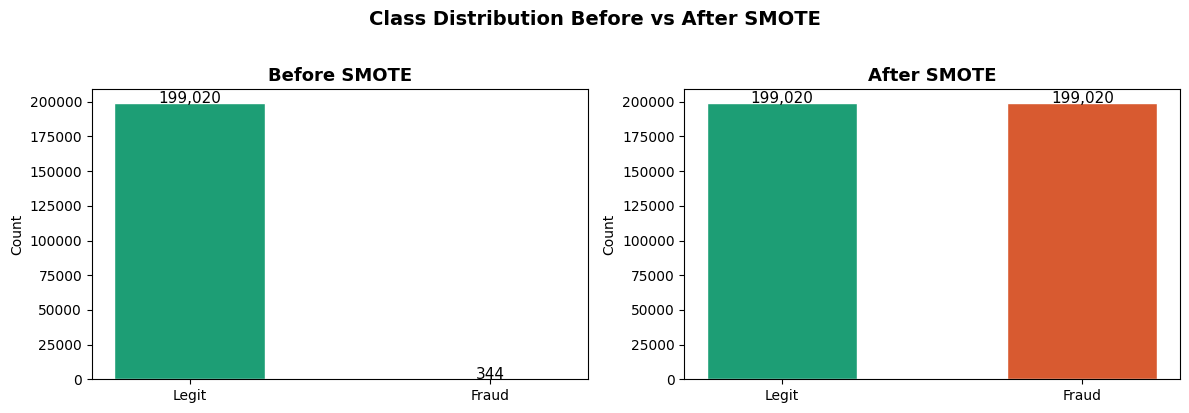

✅ Plot saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
before_counts = y_train.value_counts()
axes[0].bar(['Legit', 'Fraud'], before_counts.values,
            color=['#1D9E75', '#D85A30'], edgecolor='white', width=0.5)
axes[0].set_title('Before SMOTE', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

# After SMOTE
after_counts = pd.Series(y_train_smote).value_counts()
axes[1].bar(['Legit', 'Fraud'], after_counts.values,
            color=['#1D9E75', '#D85A30'], edgecolor='white', width=0.5)
axes[1].set_title('After SMOTE', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Count')
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=11)

plt.suptitle('Class Distribution Before vs After SMOTE', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/data/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

## Step 5: Save Processed Data
Save all splits so Week 3 model training can directly load them  
without repeating all preprocessing steps.

In [15]:
import os
os.makedirs('../data/processed', exist_ok=True)

# Save as numpy arrays (faster than CSV for ML)
np.save('../data/processed/X_train_smote.npy', X_train_smote)
np.save('../data/processed/y_train_smote.npy', y_train_smote)
np.save('../data/processed/X_val_scaled.npy',  X_val_scaled)
np.save('../data/processed/y_val.npy',         y_val.values)
np.save('../data/processed/X_test_scaled.npy', X_test_scaled)
np.save('../data/processed/y_test.npy',        y_test.values)

# Save scaler for use in FastAPI backend later
import joblib
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')

print("✅ All processed data saved!")
print("\nSaved files:")
for f in os.listdir('../data/processed'):
    size = os.path.getsize(f'../data/processed/{f}') / (1024*1024)
    print(f"  {f} — {size:.1f} MB")
print(f"\n  scaler.pkl saved in models/")

✅ All processed data saved!

Saved files:
  X_test_scaled.npy — 9.8 MB
  X_train_smote.npy — 91.1 MB
  X_val_scaled.npy — 9.8 MB
  y_test.npy — 0.3 MB
  y_train_smote.npy — 3.0 MB
  y_val.npy — 0.3 MB

  scaler.pkl saved in models/


In [17]:
# Reload and verify everything saved correctly
X_tr = np.load('../data/processed/X_train_smote.npy')
y_tr = np.load('../data/processed/y_train_smote.npy')
X_v  = np.load('../data/processed/X_val_scaled.npy')
X_te = np.load('../data/processed/X_test_scaled.npy')

print("✅ Verification — All files load correctly!")
print(f"\nX_train_smote: {X_tr.shape}")
print(f"y_train_smote: {y_tr.shape}  |  Fraud: {y_tr.sum():,}")
print(f"X_val:         {X_v.shape}")
print(f"X_test:        {X_te.shape}")

✅ Verification — All files load correctly!

X_train_smote: (398040, 30)
y_train_smote: (398040,)  |  Fraud: 199,020
X_val:         (42721, 30)
X_test:        (42722, 30)


## Week 2 Summary

| Step | What we did | Why |
|---|---|---|
| Split 70/15/15 | Divided data before any processing | Prevent data leakage |
| StandardScaler | Scaled Amount + Time to same range | Model treats all features equally |
| SMOTE | Created synthetic fraud samples | Fix 0.17% class imbalance |
| Saved .npy files | Stored processed arrays | Week 3 loads directly, no reprocessing |

### Key Numbers
- Training samples after SMOTE: ~398,000 (balanced 50/50)
- Validation samples: 42,721 (original distribution)
- Test samples: 42,722 (original distribution)
- Scaler saved: models/scaler.pkl (needed for deployment)

### Ready for Week 3: Model Training!